In [ ]:
!pip install numpy pandas seaborn matplotlib joblib scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
array([0.37454012, 0.95071431, 0.73199394])

In [ ]:
np.random.seed(42) #Đặt seed cho hàm sinh số ngẫu nhiên => kết quả để có thể giả lập
n_samples = 1000000
X_data = np.random.uniform(1, 10, (n_samples, 10)) # 10 đặc trưng ảnh hưởng đến điểm số

columns = [
    'Hours_Studied', # Số giờ học
    'Sleep_Hours',# Số giờ ngủ
    'Extra', # Hoạt động ngoại khóa
    'Health_Index', # Chỉ số sức khỏe
    'Parental_Involve', # Mức độ quan tâm của phụ huynh
    'Tutoring_Hours', # Số giờ học thêm
    'Internet_Usage', # Số giờ lướt mạng
    'Self-Study', # Tự học
    'Attendance', # Điểm danh
    'Motivation' # Mức độ động viên

    ]

data = pd.DataFrame(X_data, columns=columns)

data['Grades'] = (
    5 * data['Hours_Studied'] +
    3 * data['Self-Study'] +
    2 * data['Parental_Involve'] +
    1.5 * data['Tutoring_Hours'] -
    2 * data['Internet_Usage']
    # np.random.normal(0,5, n_samples)

)

In [ ]:
data.head()

,Hours_Studied,Sleep_Hours,Extra,Health_Index,Parental_Involve,Tutoring_Hours,Internet_Usage,Self-Study,Attendance,Motivation,Grades
0,4.370861,9.556429,7.587945,6.387926,2.404168,2.403951,1.522753,8.795585,6.410035,7.372653,52.680718
1,1.185260,9.729189,8.491984,2.911052,2.636425,2.650641,3.738180,5.722808,4.887505,3.621062,28.238799
2,6.506676,2.255445,3.629302,4.297257,5.104630,8.066584,2.797064,5.628110,6.331731,1.418054,67.915446
3,6.467904,2.534717,1.585464,9.539970,9.690688,8.275576,3.741524,1.879049,7.158097,4.961372,64.821061
4,2.098344,5.456592,1.309497,9.183884,3.329020,6.962701,3.805400,5.680612,5.920393,2.663690,35.421047


In [ ]:
print("Thông tin dataset")
print(data.info())

Thông tin dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Hours_Studied     1000000 non-null  float64
 1   Sleep_Hours       1000000 non-null  float64
 2   Extra             1000000 non-null  float64
 3   Health_Index      1000000 non-null  float64
 4   Parental_Involve  1000000 non-null  float64
 5   Tutoring_Hours    1000000 non-null  float64
 6   Internet_Usage    1000000 non-null  float64
 7   Self-Study        1000000 non-null  float64
 8   Attendance        1000000 non-null  float64
 9   Motivation        1000000 non-null  float64
 10  Grades            1000000 non-null  float64
dtypes: float64(11)
memory usage: 83.9 MB
None


<function matplotlib.pyplot.show(close=None, block=None)>

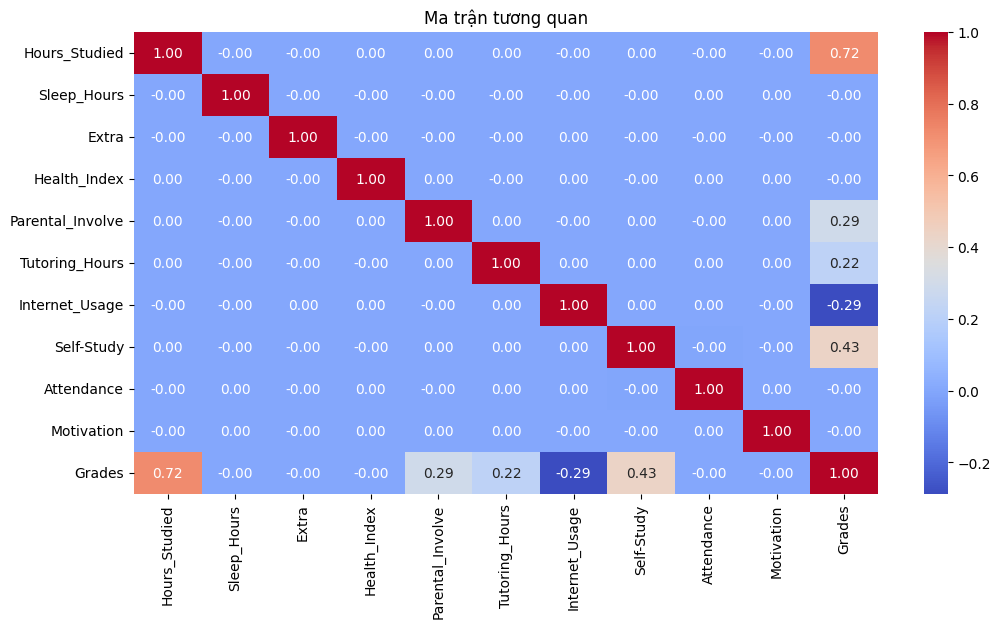

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan')
plt.show

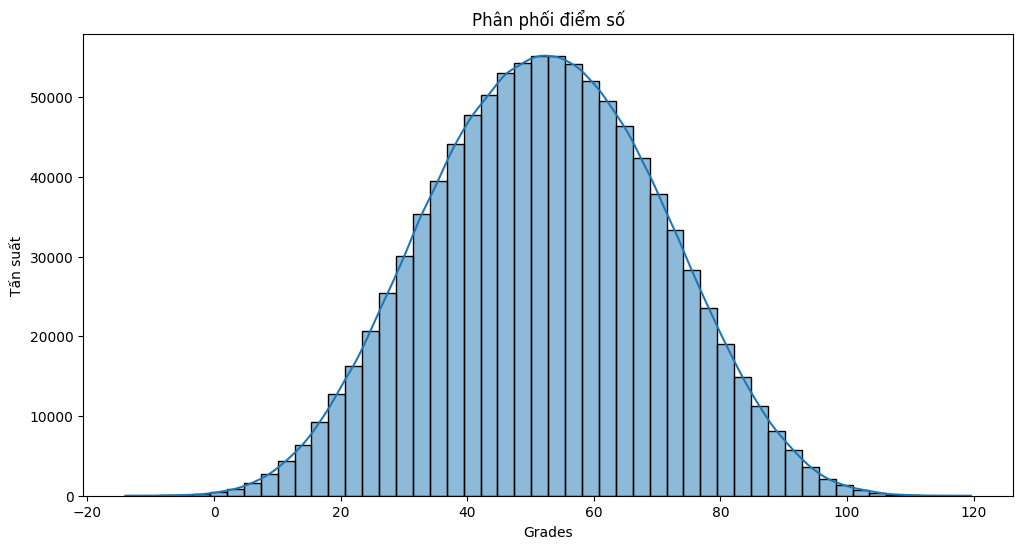

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(data['Grades'], bins=50, kde=True)
plt.xlabel('Grades')
plt.ylabel('Tấn suất')
plt.title('Phân phối điểm số')
plt.show()

In [ ]:
X = data.drop(columns=['Grades']) # chia tập dữ liệu x là input y là out put
y = data['Grades']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random dữ liệu chia train và test

In [ ]:
model = LinearRegression() # khởi tạo hàm 
model.fit(X_train, y_train) # học và huấn luyện 

LinearRegression()

In [ ]:
joblib.dump(model, 'Linear.pkl') # lưu lại mô hình 
print("Mô hình đã được lưu")

Mô hình đã được lưu


In [ ]:
y_pred = model.predict(X_test) # là y do mô hình dự đoán 

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(mae, mse, r2)

4.002354973042497 25.12682305285946 0.9229347973584643


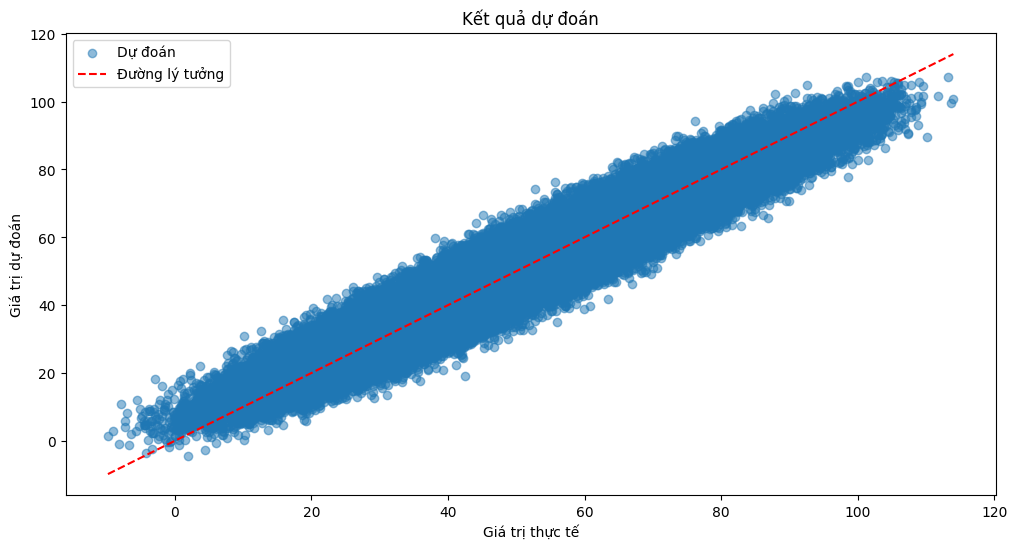

In [ ]:
plt.figure(figsize=(12,6))
plt.scatter(y_test, y_pred, alpha=0.5, label = "Dự đoán")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Đường lý tưởng")
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('Kết quả dự đoán')
plt.legend()
plt.show()

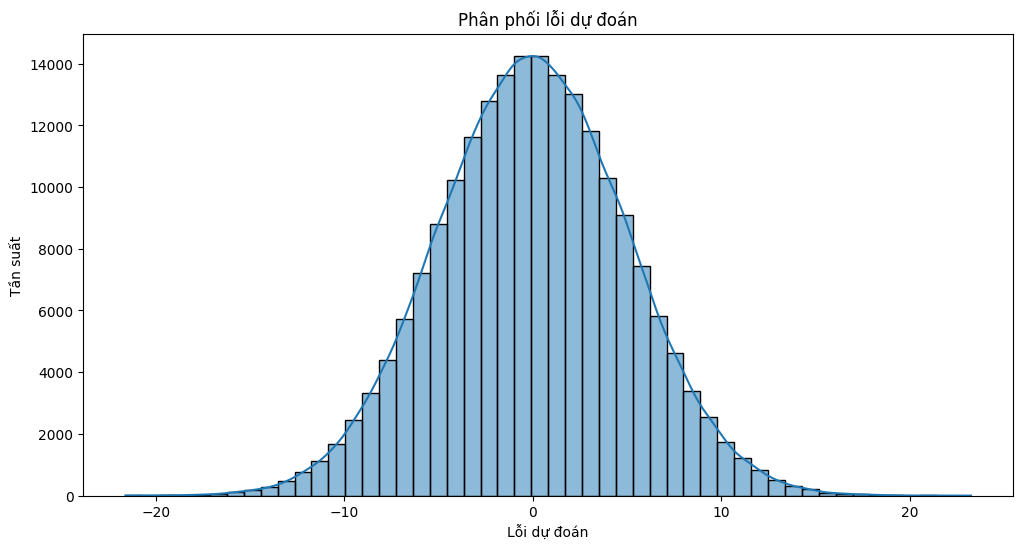

In [ ]:
errors = y_test - y_pred
plt.figure(figsize=(12,6))
sns.histplot(errors, bins=50, kde=True)
plt.xlabel('Lỗi dự đoán')
plt.ylabel('Tần suất')
plt.title('Phân phối lỗi dự đoán')
plt.show()

In [ ]:
model2 = joblib.load('Linear.pkl')
all_predictions = model2.predict(X_test)

In [ ]:
print(all_predictions)

[55.85339591 47.1926102  66.75081473 ... 32.7141429  43.15063878
 34.8343555 ]


In [ ]:
prediction = model2.predict(X)

In [ ]:
results = pd.DataFrame({"Actual": y, "Predicted": prediction})
print(results.head(100))

       Actual  Predicted
0   52.680718  53.605162
1   28.238799  24.871905
2   67.915446  66.140628
3   64.821061  62.313845
4   35.421047  37.022657
..        ...        ...
95  48.811146  41.163172
96  21.817568  18.300300
97  25.627742  34.134850
98  43.621599  43.694290
99  36.701060  40.402195

[100 rows x 2 columns]
